## Hog features

In [9]:
import pathlib
import numpy as np
from skimage import io, color
from skimage.feature import hog
import matplotlib.pyplot as plt

In [10]:
IMG_NUM = '3'  # Example image number
image_path = '../data/seg_pred/seg_pred/'+IMG_NUM+'.jpg'


def analyse_img(image_path, IMG_NUM):
    # Load image
    image = io.imread(image_path)
    # Convert to grayscale
    gray_image = color.rgb2gray(image)
    # Compute HOG features
    hog_features, hog_image = hog(gray_image, pixels_per_cell=(16, 16),
                                  cells_per_block=(2, 2), visualize=True, orientations=25)
    
    gx, gy = np.gradient(gray_image)
    grad_mag = np.hypot(gx, gy)
    grad_image = grad_mag / grad_mag.max() if grad_mag.max() > 0 else grad_mag

    return hog_features, hog_image, grad_image

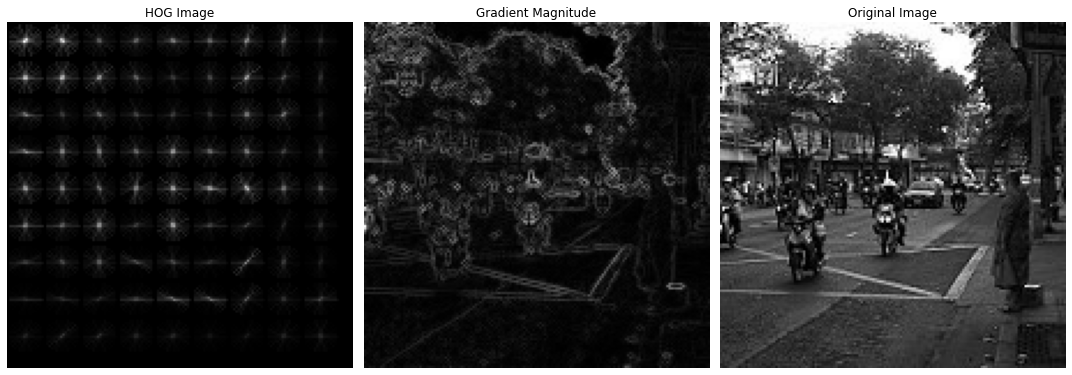

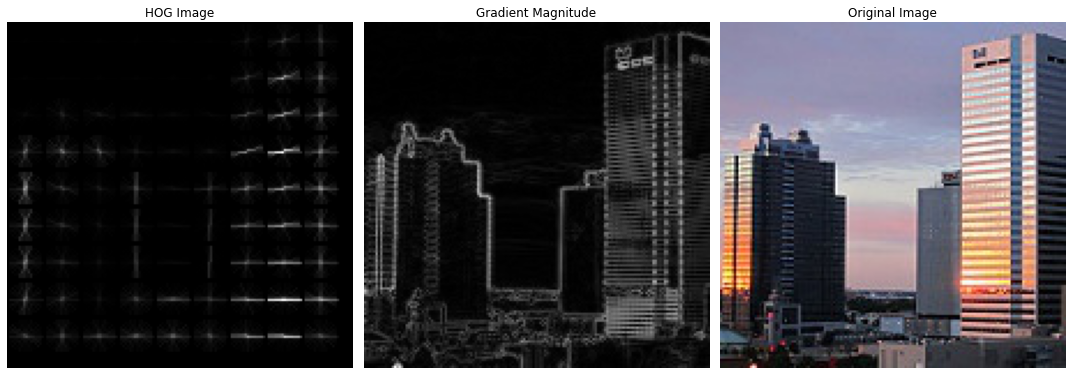

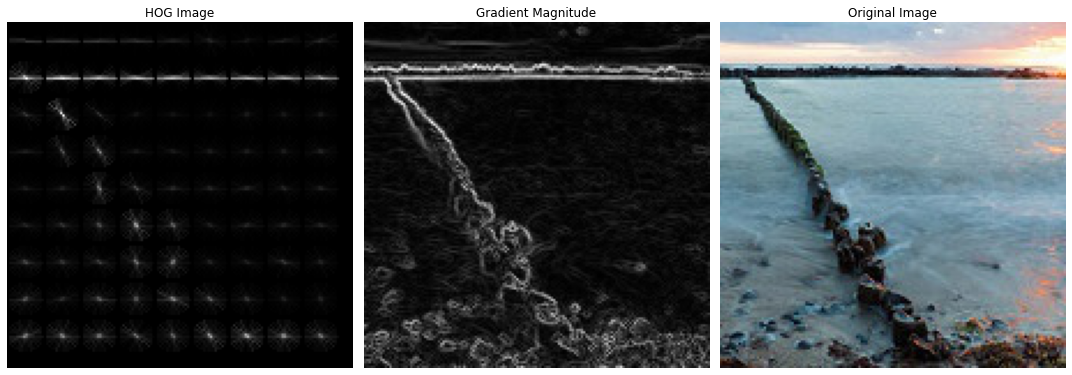

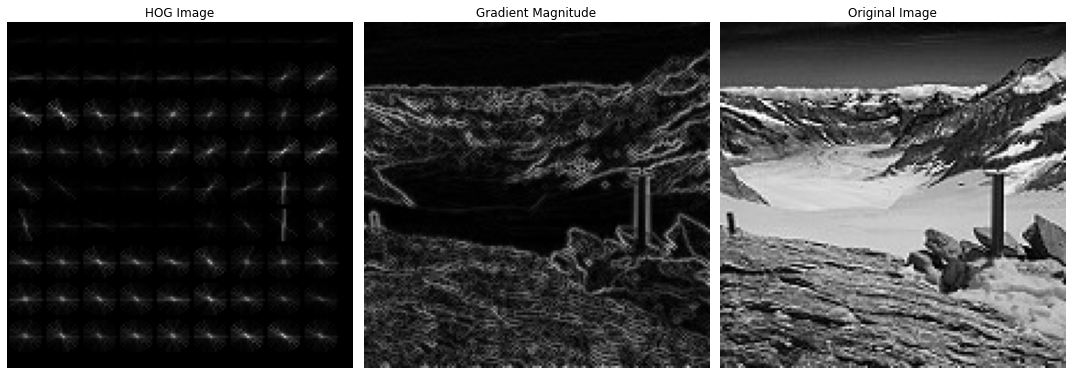

In [11]:
#Visualize HOG features

IMG_LIST = ['3', '5', '6', '11']


for IMG_NUM in IMG_LIST:
    image_path = '../data/seg_pred/seg_pred/'+IMG_NUM+'.jpg'
    hog_features, hog_image, grad_image = analyse_img(image_path, IMG_NUM=IMG_NUM)

    plt.figure(figsize=(15, 6))
    plt.subplot(1, 3, 1)
    plt.title('HOG Image')
    plt.imshow(hog_image, cmap='gray')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.title('Gradient Magnitude')
    plt.imshow(grad_image, cmap='gray')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.title('Original Image')
    plt.imshow(io.imread(image_path))
    plt.axis('off')

    plt.tight_layout()
    plt.show()

